In [1]:
# Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the
# effect of different learning rates and the number of epochs on model performance.

In [3]:
%pip install tensorflow

  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 5.0/351.2 MB 37.4 MB/s eta 0:00:10
   - -------------------------------------- 10.5/351.2 MB 30.8 MB/s eta 0:00:12
   - -------------------------------------- 13.4/351.2 MB 21.3 MB/s eta 0:00:16
   -- ------------------------------------- 19.4/351.2 MB 23.0 MB/s eta 0:00:15
   -- ------------------------------------- 25.7/351.2 MB 24.2 MB/s eta 0:00:14
   --- ------------------------------------ 31.2/351.2 MB 24.4 MB/s eta 0:00:14
   ---- ----------------------------------- 35.1/351.2 MB 23.8 MB/s eta 0:00:14
   ---- ----------------------------------- 38.8/351.2 MB 22.9 MB/s eta 0:00:14
   ---- ----------------------------------- 41.7/351.2 MB 21.9 MB/s eta 0:00:15
   ----- ---------------------------------- 44.6/351.2 MB 21.6 MB/s eta 0:00:15
   ----- ---------------------------------- 46.7/351.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


In [4]:
# Importing the required libraru=ies
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Training labels: (60000,)
Testing data: (10000, 28, 28)
Testing labels: (10000,)


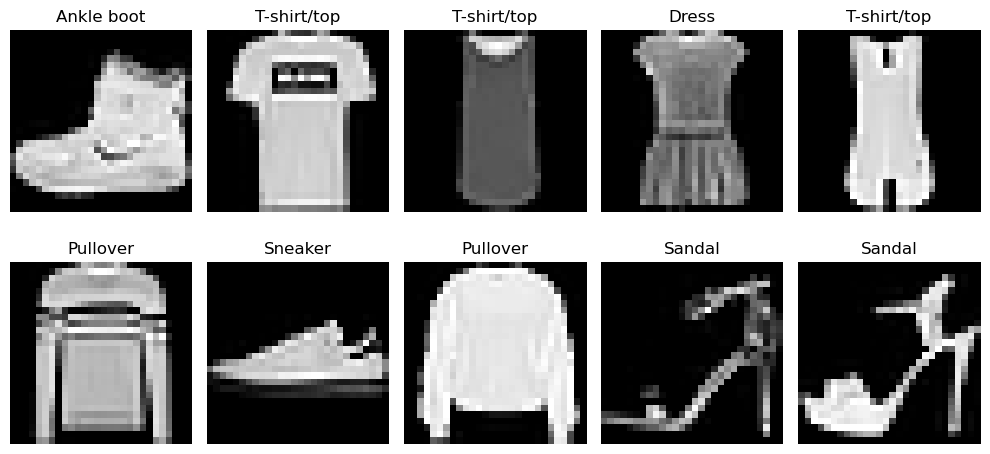

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training data:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing data:", x_test.shape)
print("Testing labels:", y_test.shape)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Preprocess the data and creating the neural network
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

print(x_train.shape)
print(x_test.shape)

# Creating the neural network
def create_model(lr):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

(60000, 784)
(10000, 784)


In [7]:
learning_rates = [0.1, 0.01, 0.001]

results = []

for lr in learning_rates:

    print("Training with learning rate:", lr)

    model = create_model(lr)

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append([lr, loss, acc])

Training with learning rate: 0.1


c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with learning rate: 0.01
Training with learning rate: 0.001


   Learning Rate      Loss  Accuracy
0          0.100  1.301262    0.4311
1          0.010  0.374079    0.8674
2          0.001  0.374429    0.8670


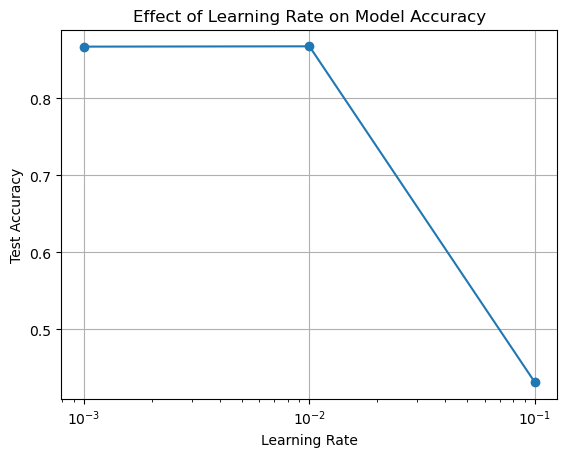

In [8]:
# Displaying the learning-rate results
df = pd.DataFrame(
    results,
    columns=['Learning Rate', 'Loss', 'Accuracy']
)

print(df)

#  plotting learning rate vs accuracy
plt.plot(
    df['Learning Rate'],
    df['Accuracy'],
    marker='o'
)

plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Effect of Learning Rate on Model Accuracy')
plt.grid()
plt.show()

c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs      Loss  Accuracy
0       5  0.365862    0.8697
1      10  0.357977    0.8729
2      20  0.360052    0.8811


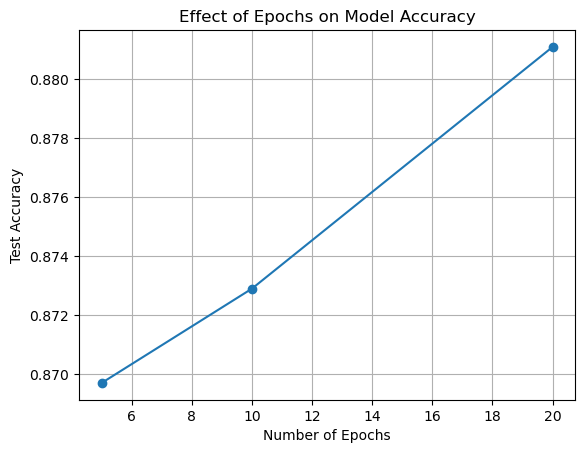

In [9]:
# Testing with diff epochs and plotting an epoch vs accuracy graph
epochs_list = [5, 10, 20]
epoch_results = []

for ep in epochs_list:
    model = create_model(0.001)

    model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    epoch_results.append([ep, loss, acc])

edf = pd.DataFrame(
    epoch_results,
    columns=['Epochs', 'Loss', 'Accuracy']
)

print(edf)

plt.plot(edf['Epochs'], edf['Accuracy'], marker='o')
plt.xlabel('Number of Epochs')
plt.ylabel('Test Accuracy')
plt.title('Effect of Epochs on Model Accuracy')
plt.grid()
plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5559 - loss: 1.3575 - val_accuracy: 0.6926 - val_loss: 0.8540
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7288 - loss: 0.7530 - val_accuracy: 0.7539 - val_loss: 0.6715
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7641 - loss: 0.6407 - val_accuracy: 0.7788 - val_loss: 0.6040
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7847 - loss: 0.5889 - val_accuracy: 0.7923 - val_loss: 0.5713
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7989 - loss: 0.5564 - val_accuracy: 0.8007 - val_loss: 0.5413
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8120 - loss: 0.5282 - val_accuracy: 0.8134 - val_loss: 0.5198
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8195 - loss: 0.5054 - val_accuracy: 0.8176 - val_loss: 0.4992
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8277 - loss: 0.4875 - val_accuracy: 0.8271 - val_

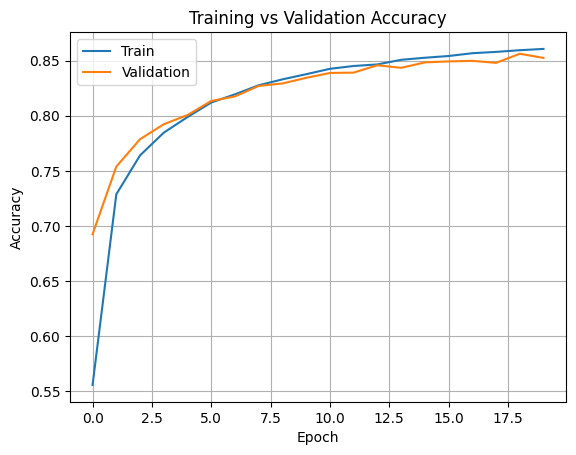

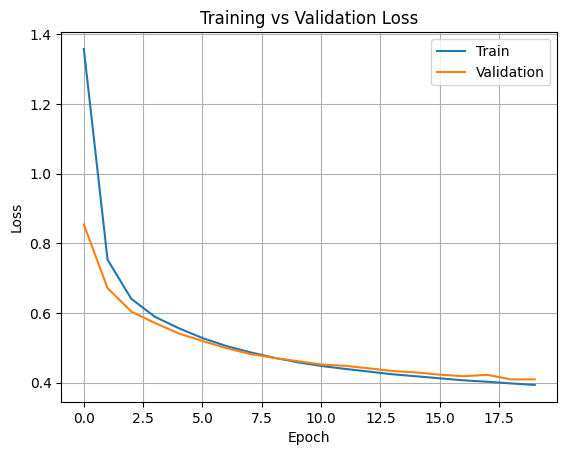

In [ ]:
model = create_model(0.001)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()